# ***二阶自适应扩散滤波***

In [1]:
import numpy as np#数值计算库
from numpy import random#随机数库

from matplotlib import pyplot as plt#绘图库
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定默认字体
plt.rcParams["axes.unicode_minus"] = False  # 解决保存图像是负号'-'显示为方块的问题
import seaborn as sns#高级绘图库
from mpl_toolkits.mplot3d import Axes3D

import pandas as pd#数据处理库

import scipy#信号处理库
from scipy import signal
from scipy.signal import sawtooth
from scipy.signal import hilbert
from scipy.signal import butter, lfilter
from scipy.signal import argrelextrema
from scipy.stats  import kurtosis
from scipy.interpolate import interp1d

import xcw_package as xcw#自定义信号处理库

from CRWU import CRWU_readdata#CRWU数据集
from CRWU import CRWU_CalFCF

In [27]:
%matplotlib inline

In [1]:
%matplotlib qt

# 导入数据

## 仿真数据

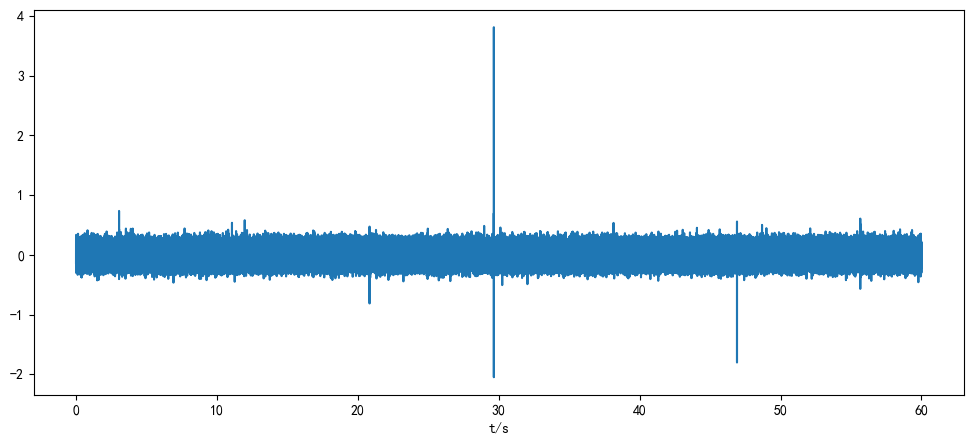

In [11]:
index=3
data=pd.read_csv(f"D:\\OneDrive\\毕业设计\\仿真冲击波形\\仿真冲击序列{index}(含噪声).csv",header=None)
data=data.values.flatten()
simSig=xcw.Signal(data,f_s=12800)
simSig.plot()

## 风机轴承

In [3]:
file_path="D:\那仁风电场偏航轴承数据/index.csv"
index=pd.read_csv(file_path,encoding="utf_8_sig")
sample_rate="51200Hz"
fault_type="3#径向"
measure_point="测点1"   
database=index[(index['采样频率']==sample_rate)&(index['故障类型']==fault_type)&(index['测点']==measure_point)]
database

,设备,测点,采样频率,日期,故障类型,文件路径
120,那仁20K,测点1,51200Hz,2023-10-19 14:11:19,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
121,那仁20K,测点1,51200Hz,2023-10-19 14:12:40,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
122,那仁20K,测点1,51200Hz,2023-10-19 14:13:59,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
123,那仁20K,测点1,51200Hz,2023-10-19 14:15:52,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
124,那仁20K,测点1,51200Hz,2023-10-19 14:17:17,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
125,那仁20K,测点1,51200Hz,2023-10-19 14:18:39,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
126,那仁20K,测点1,51200Hz,2023-10-19 14:19:59,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
127,那仁20K,测点1,51200Hz,2023-10-19 14:21:18,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
128,那仁20K,测点1,51200Hz,2023-10-19 14:22:37,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...
129,那仁20K,测点1,51200Hz,2023-10-19 14:24:27,3#径向,D:\那仁风电场偏航轴承数据/时域波形数据\那仁20K_3#径向_T219e2236b89测...


信号长度: 1536000
采样频率: 51200.0 Hz
采样间隔: 0.000020 s
信号采样时长: 30.000 s
频谱频率分辨率: 0.033 Hz
可分析频率上限: 25600.0 Hz



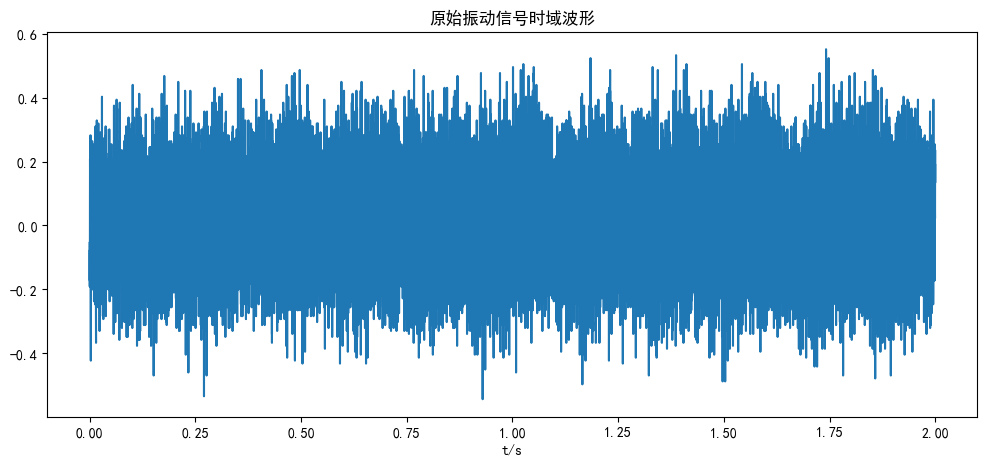

In [6]:
data=database.iloc[6]
data_path=data['文件路径']
data_index=data.name+2
# 读取文件
with open(data_path, 'r') as file:
    data_str = file.read()
    data_list = data_str.split(',')

# 将字符串数据转换为浮点数，并创建 NumPy 数组
data_array = np.array(data_list, dtype=float)
Sig=xcw.Signal(data_array,f_s=51200)
Sig.info()
Sig.plot(title="原始振动信号时域波形",time=(0,2))

信号长度: 384000
采样频率: 12800.0 Hz
采样间隔: 0.000078 s
信号采样时长: 30.000 s
频谱频率分辨率: 0.033 Hz
可分析频率上限: 6400.0 Hz



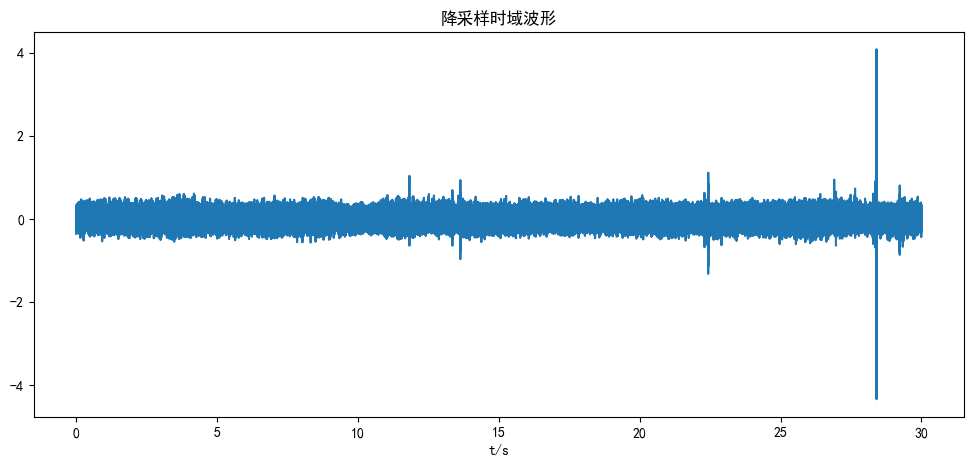

In [33]:
rsSig=xcw.resample(Sig,12800,int(Sig.N*12800/51200),0)
rsSig.info()
rsSig.plot(title='降采样时域波形')

In [9]:
CRWU_CalFCF(38,1900,72,3/360,45)

{'BPFO': 0.2957573593128807,
 'BPFI': 0.3042426406871193,
 'BSF': 0.20829166666666668}

# 仿真数据测试

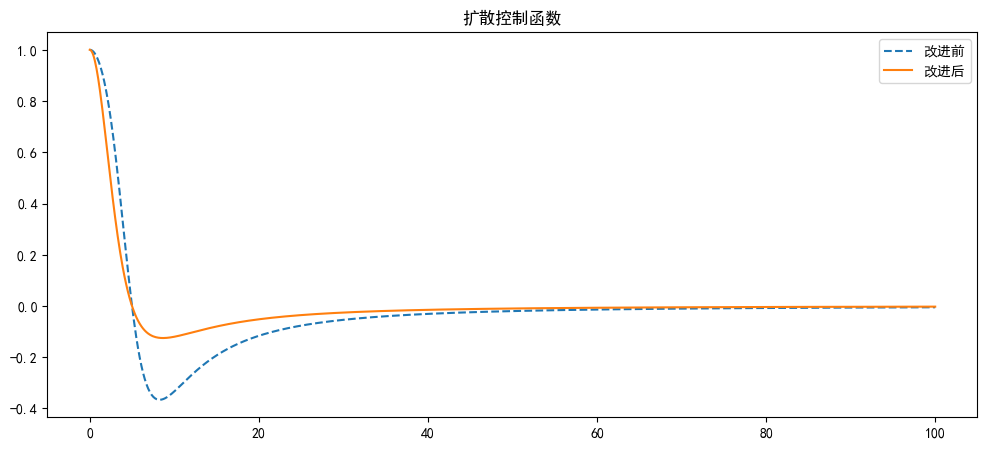

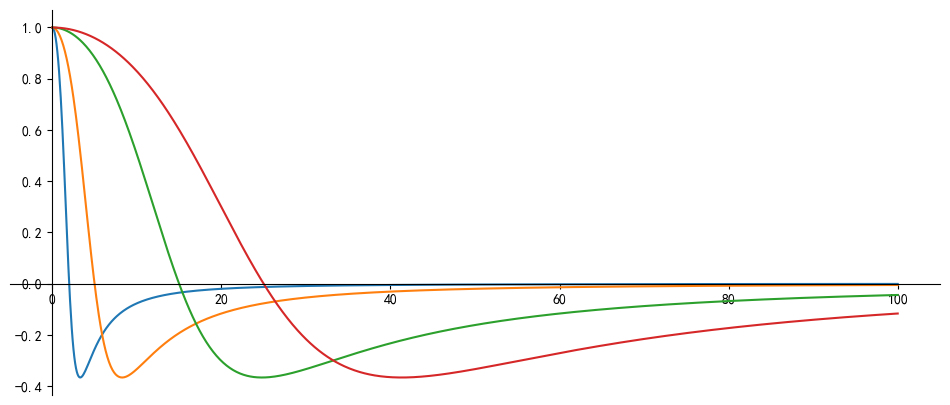

In [9]:
def diffusion1(E,lam):
    return (1-(E/lam)**2)/(1+0.5*(E/lam)**4)

def diffusion2(E,lam):
    return -((lam*E)**2-lam**4)/(E**4+2*(lam*E)**2+lam**4)

def diffusion3(E,lam):
    S=np.sqrt(2)*lam
    return np.where(E<=S,5/2*(E**4)/(S**4)-3/(S**2)*(E**2)+1/2,0)

x=np.linspace(0,100,1000)
y1=diffusion1(x,5)
y2=diffusion2(x,5)
plt.figure(figsize=(12, 5))
plt.plot(x,y1,label='改进前',linestyle='--')
plt.plot(x,y2,label='改进后')
plt.legend()
plt.title('扩散控制函数')
plt.savefig('扩散控制函数.svg',format='svg')
plt.show()

plt.figure(figsize=(12,5))
for lam in [2,5,15,25]:
    plt.plot(x,diffusion1(x,lam),label=f'λ={lam}')

ax = plt.gca()  # 获取当前的 axes
ax.spines['right'].set_color('none')  # 隐藏右边的边框
ax.spines['top'].set_color('none')  # 隐藏上面的边框
ax.xaxis.set_ticks_position('bottom')  # 设置 x 轴刻度在下面的边框
ax.yaxis.set_ticks_position('left')  # 设置 y 轴刻度在左边的边框
ax.spines['bottom'].set_position(('data',0))  # 将下面的边框移动到 y=0 的位置
ax.spines['left'].set_position(('data', 0))  # 将左边的边框移动到 x=0 的位置


plt.show()

核心算法代码

In [4]:
def f_d2(x):
    kernel=[-1/12,4/3,-5/2,4/3,-1/12]#二阶导数的5点差分系数
    return np.convolve(x,kernel,'same')

def Gaussian(x,sigma):#标准高斯函数
    return np.exp(-x**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

def diffusion(E,lam,nperseg=None):#扩散控制函数
    if type(lam)!=list:#全局阈值  
        return (1-(E/lam)**2)/(1+0.5*(E/lam)**4)
    else:#局部阈值
        res=[]
        E_seg=np.array_split(E,len(E)/nperseg)#对输入特征进行分割
        for i,seg in enumerate(E_seg):
            res.append((1-(seg/lam[i])**2)/(1+0.5*(seg/lam[i])**4))#分段代入扩散控制函数，每段使用局部阈值
        res=np.concatenate(res)#合并得全局扩散系数
        return res

def PHI(data,lam,G,nperseg=None):
    data=np.square(data)#平方计算方差
    E=np.convolve(data,G,'same')#卷积得信号功率流，也即时变方差
    res=diffusion(E,lam,nperseg)#局部阈值下的扩散系数或全局阈值下的扩散系数，取决于lam的类型
    return res

def plot_nonlineardiffusion(s,window,kappa=2,iterations=100,dt=0.2,title=None,result=False):
    """
    二阶自适应扩散滤波

    参数:
    [xcw.Signal]s:Signal对象
    window:计算信号功率流的高斯卷积核窗长
    kappa:局部阈值倍数，默认为2
    iterations:迭代次数，默认为100
    dt:迭代步长，默认为0.2
    title:图像标题，默认为None
    result:是否返回滤波后的数据，默认为False

    返回:
    [np.array]滤波后的数据
    """
    data=s.data.copy()

    #根据window生成高斯卷积核，在扩散中保持不变
    time=np.arange(0,window/2,s.dt)#高斯平滑窗单边长度为3倍标准差
    time=np.append(-time[::-1],time[1:])#生成时间序列
    G = Gaussian(time,window/6)  # 生成高斯核函数
    G = G / np.sum(G)  # 归一化

    #根据原始信号计算局部阈值，在扩散中保持不变
    E=np.convolve(np.square(data),G,'same')
    threshold=[]
    nperseg=int(3*window/s.dt)#分段阈值，每段长度3倍卷积核窗长
    E_seg=np.array_split(E,len(E)//nperseg)
    for seg in E_seg:
        threshold.append(kappa*seg.mean())#计算局部阈值，取为段内方差平均值的2倍使得缓变趋势不被增强，瞬变趋势得到增强

    #迭代扩散
    for i in range(iterations):
        p=PHI(data,threshold,G,nperseg)#扩散系数
        d2=f_d2(data)#二阶导数
        if i!=0:
            inc=np.std(d2*p)-np.std(delta)#增量收敛判断
            if np.abs(inc/delta.std())<0.05:#扩散增量收敛判断
                delta=d2*p
                data=delta*dt+data#最后一次迭代
                break#增量收敛则跳出迭代
        delta=d2*p#扩散增量
        data=delta*dt+data#迭代计算,dt=0.2为标准步长

    print(f"迭代{i}次")

    #绘制扩散后时域波形    
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

算法超参数

In [27]:
window=0.005

In [ ]:
time=np.arange(0,window/2,simSig.dt)#高斯平滑窗单边长度为3倍标准差
time=np.append(-time[::-1],time[1:])#生成时间序列
G = Gaussian(time,window/6)  # 生成高斯核函数
G=G/G.sum()

E=np.convolve(np.square(simSig.data),G,'same')#卷积得信号功率流，也即时变方差
threshold=[]
nperseg=int(3*window/simSig.dt)#分段阈值，每段长度3倍卷积核窗长
E_seg=np.array_split(E,len(E)//nperseg)#分隔，每段长度为nperseg
for seg in E_seg:
    threshold.append(2*seg.mean())#计算局部阈值，取为段内方差平均值的2倍

p=PHI(simSig.data,threshold,G,nperseg)

d2=f_d2(simSig.data)
delta=d2*p*0.2
plt.figure(figsize=(12, 16))

plt.subplot(411)
plt.plot(simSig.t_values,E)
plt.title('信号方差')

plt.subplot(412)
plt.plot(np.linspace(0,simSig.T,len(threshold)),threshold)
plt.title('局部阈值')

plt.subplot(413)
plt.plot(simSig.t_values,p)
plt.title('扩散系数')

plt.subplot(414)
plt.plot(simSig.t_values,delta)
plt.title('迭代加值')

plt.tight_layout()
plt.show()

窗长window的估计置信度检验

In [6]:
from scipy.stats import chi2

def chi2_limit(N, alpha):
    df=N-1
    limit=np.zeros(2)
    limit[0]=chi2.ppf(1/2-alpha/2,df)
    limit[1]=chi2.ppf(1/2+alpha/2,df)
    limit=limit/(df)
    return limit

limit=chi2_limit(G.shape[0],simSig.data.var())
print(f"95%置信区间为{limit}")

95%置信区间为[0.99626065 0.9984933 ]


In [21]:
simSig=xcw.resample(simSig,12800,int(30/simSig.dt),0)  

迭代22次


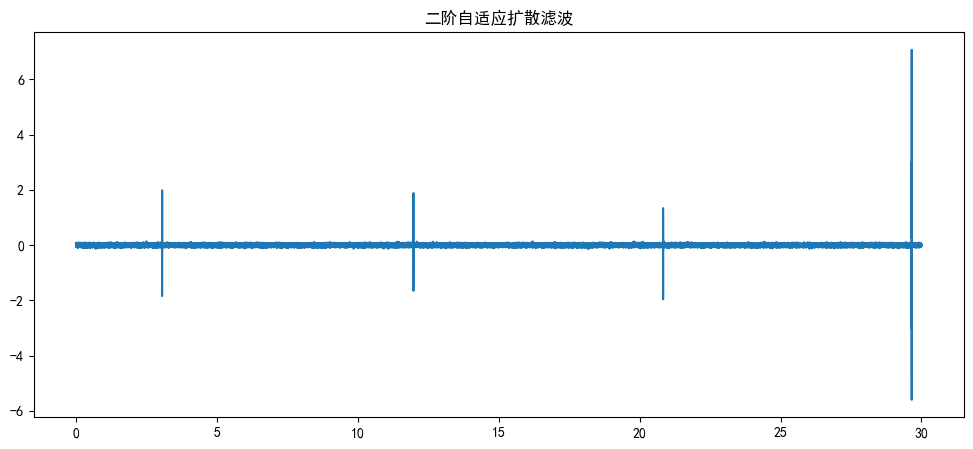

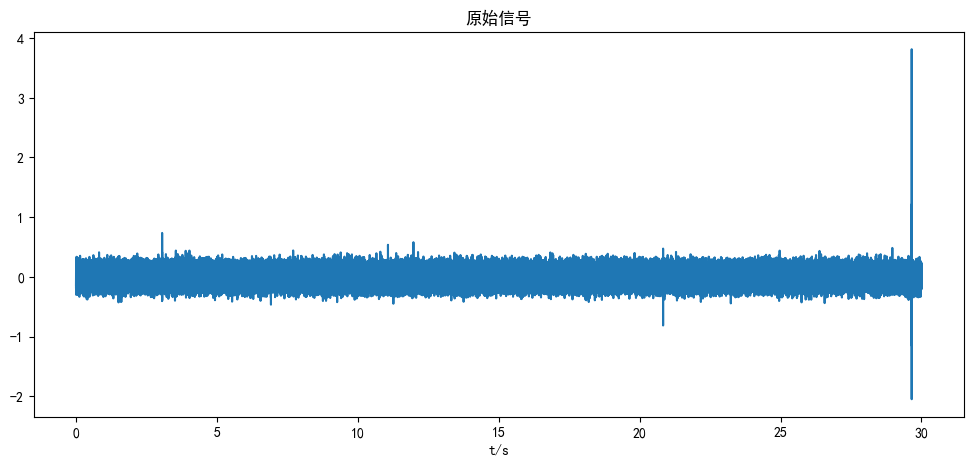

In [22]:
data=plot_nonlineardiffusion(simSig,window=0.005,kappa=2,iterations=100,dt=0.2,title="二阶自适应扩散滤波",result=True)
simSig.plot(title="原始信号")
dfSig=xcw.Signal(data,f_s=simSig.f_s)

测试扩散滤波效果

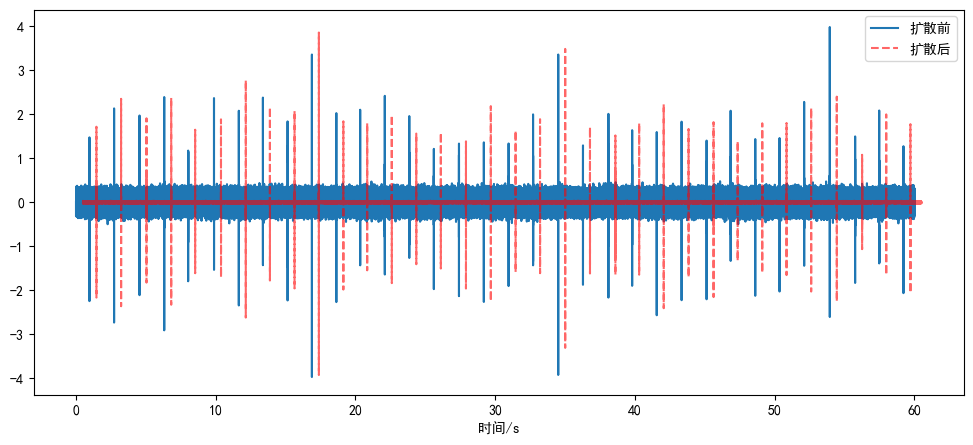

原始信号峭度为13.927617437350946
扩散后信号峭度为1616.8126225227645


In [73]:
plt.figure(figsize=(12, 5))
plt.plot(simSig.t_values,simSig.data,label='扩散前')
plt.plot(dfSig.t_values+0.5,dfSig.data*0.35,color='r',linestyle='--',alpha=0.6,label='扩散后')
plt.legend()
plt.xlabel('时间/s')
plt.show()
print(f"原始信号峭度为{kurtosis(simSig.data)}")
print(f"扩散后信号峭度为{kurtosis(dfSig.data)}")

In [ ]:
E=np.convolve(np.square(dfSig.data),G,'same')#卷积得信号功率流，也即时变方差

p=PHI(dfSig.data,threshold,G,nperseg)#扩散系数

d2=f_d2(dfSig.data)
delta=d2*p*0.2

plt.figure(figsize=(12, 16))

plt.subplot(411)
plt.plot(dfSig.t_values,E)
plt.title('信号方差')

plt.subplot(412)
plt.plot(np.linspace(0,dfSig.T,len(threshold)),threshold)
plt.title('局部阈值')

plt.subplot(413)
plt.plot(dfSig.t_values,p)
plt.title('扩散系数')

plt.subplot(414)
plt.plot(dfSig.t_values,delta)
plt.title('迭代加值')

plt.tight_layout()
plt.show()

# 实际数据测试

In [42]:
def f_d2(x):
    kernel=[-1/12,4/3,-5/2,4/3,-1/12]#二阶导数的5点差分系数
    return np.convolve(x,kernel,'same')

def Gaussian(x,sigma):#标准高斯函数
    return np.exp(-x**2/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

def diffusion(E,lam,nperseg=None):#扩散控制函数
    if type(lam)!=list:#全局阈值  
        return (1-(E/lam)**2)/(1+0.5*(E/lam)**4)
    else:#局部阈值
        res=[]
        E_seg=np.array_split(E,len(E)/nperseg)#对输入特征进行分割
        for i,seg in enumerate(E_seg):
            res.append((1-(seg/lam[i])**2)/(1+0.5*(seg/lam[i])**4))#分段代入扩散控制函数，每段使用局部阈值
        res=np.concatenate(res)#合并得全局扩散系数
        return res

def PHI(data,lam,G,nperseg=None):
    data=np.square(data)#平方计算方差
    E=np.convolve(data,G,'same')#卷积得信号功率流，也即时变方差
    res=diffusion(E,lam,nperseg)#局部阈值下的扩散系数或全局阈值下的扩散系数，取决于lam的类型
    return res

def plot_nonlineardiffusion(s,window,kappa=2,iterations=100,dt=0.2,title=None,result=False):
    """
    二阶自适应扩散滤波

    参数:
    [xcw.Signal]s:Signal对象
    window:计算信号功率流的高斯卷积核窗长
    kappa:局部阈值倍数，默认为2
    iterations:迭代次数，默认为100
    dt:迭代步长，默认为0.2
    title:图像标题，默认为None
    result:是否返回滤波后的数据，默认为False

    返回:
    [np.array]滤波后的数据
    """
    data=s.data.copy()

    #根据window生成高斯卷积核，在扩散中保持不变
    time=np.arange(0,window/2,s.dt)#高斯平滑窗单边长度为3倍标准差
    time=np.append(-time[::-1],time[1:])#生成时间序列
    G = Gaussian(time,window/6)  # 生成高斯核函数
    G = G / np.sum(G)  # 归一化

    #根据原始信号计算局部阈值，在扩散中保持不变
    E=np.convolve(np.square(data),G,'same')
    threshold=[]
    nperseg=int(3*window/s.dt)#分段阈值，每段长度3倍卷积核窗长
    E_seg=np.array_split(E,len(E)//nperseg)
    for seg in E_seg:
        threshold.append(kappa*seg.mean())#计算局部阈值，取为段内方差平均值的2倍使得缓变趋势不被增强，瞬变趋势得到增强

    #迭代扩散
    for i in range(iterations):
        p=PHI(data,threshold,G,nperseg)#扩散系数
        d2=f_d2(data)#二阶导数
        if i!=0:
            inc=np.std(d2*p)-np.std(delta)#增量收敛判断
            if np.abs(inc/delta.std())<0.01:#扩散增量收敛判断
                delta=d2*p
                data=delta*dt+data#最后一次迭代
                break#增量收敛则跳出迭代
        delta=d2*p#扩散增量
        data=delta*dt+data#迭代计算,dt=0.2为标准步长

    print(f"迭代{i}次")

    #绘制扩散后时域波形    
    plt.figure(figsize=(12, 5))
    plt.plot(s.t_values, data)
    plt.title(title)
    plt.show()
    if result:
        return data
    else:
        return None

In [8]:
window=0.005

In [ ]:
time=np.arange(0,window/2,rsSig.dt)#高斯平滑窗单边长度为3倍标准差
time=np.append(-time[::-1],time[1:])#生成时间序列
G = Gaussian(time,window/6)  # 生成高斯核函数
G=G/G.sum()

E=np.convolve(np.square(rsSig.data),G,'same')#卷积得信号功率流，也即时变方差
threshold=[]
nperseg=int(3*window/rsSig.dt)#分段阈值，每段长度3倍卷积核窗长
E_seg=np.array_split(E,len(E)//nperseg)#分隔，每段长度为nperseg
for seg in E_seg:
    threshold.append(3*seg.mean())#计算局部阈值，取为段内方差平均值的2倍

p=PHI(rsSig.data,threshold,G,nperseg)

d2=f_d2(rsSig.data)
delta=d2*p*0.2
plt.figure(figsize=(12, 16))

plt.subplot(411)
plt.plot(rsSig.t_values,E)
plt.title('信号方差')

plt.subplot(412)
plt.plot(np.linspace(0,rsSig.T,len(threshold)),threshold)
plt.title('局部阈值')

plt.subplot(413)
plt.plot(rsSig.t_values,p)
plt.title('扩散系数')

plt.subplot(414)
plt.plot(rsSig.t_values,delta)
plt.title('迭代加值')

plt.tight_layout()
plt.show()

迭代25次


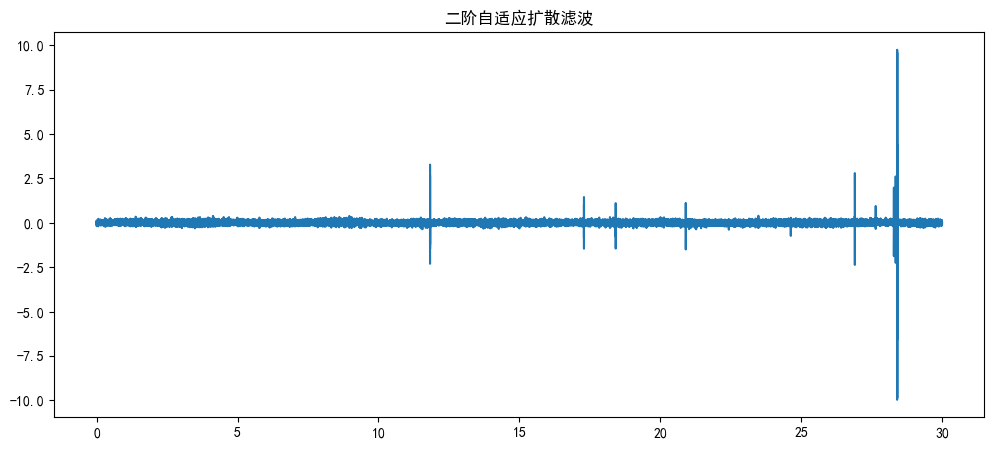

In [50]:
data=plot_nonlineardiffusion(rsSig,window=0.005,kappa=2.3,title='二阶自适应扩散滤波',result=True)
dfSig=xcw.Signal(data,f_s=rsSig.f_s)

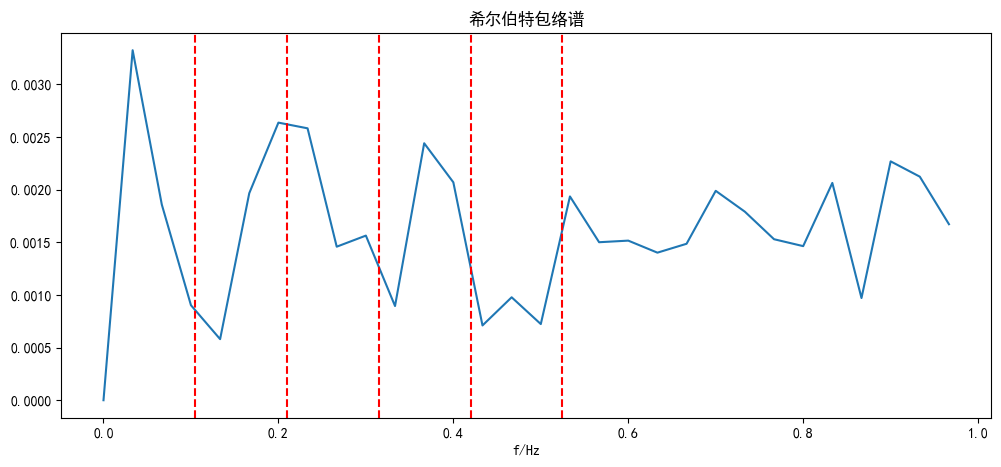

In [49]:
from scipy.fft import fft
s=dfSig
f_scope=[0,1]
analyze = hilbert(s.data)
magnitude = np.abs(analyze)  # 解析信号幅值，即原信号包络
magnitude-=np.mean(magnitude)#去除直流分量
data=np.abs(fft(magnitude))/s.N
frequence=s.f_values
if f_scope != 0:
    mask = (frequence >= f_scope[0]) & (frequence <= f_scope[1])
plt.figure(figsize=(12,5))
plt.plot(frequence[mask],data[mask])
plt.axvline(x=1/9.53,color='r',linestyle='--')
plt.axvline(x=2/9.53,color='r',linestyle='--')
plt.axvline(x=3/9.53,color='r',linestyle='--')
plt.axvline(x=4/9.53,color='r',linestyle='--')
plt.axvline(x=5/9.53,color='r',linestyle='--')
plt.xlabel('f/Hz')
plt.title("希尔伯特包络谱")
plt.show()
